In [10]:
import pandas as pd

df = pd.read_excel("../data/Placement_data.xlsx")

df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,Placement Status
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [21]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 12)


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  str    
 8   PlacementTraining          10000 non-null  str    
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  Placement Status           10000 non-null  str    
dtypes: float64(2), int64(7), str(3)
memory usage: 1.0 MB


In [13]:
df.isnull().sum()

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
Placement Status             0
dtype: int64

In [ ]:
df["Placement Status"].value_counts()

Placement Status
NotPlaced    5803
Placed       4197
Name: count, dtype: int64

In [16]:
df["Placement Status"].value_counts(normalize=True)*100

Placement Status
NotPlaced    58.03
Placed       41.97
Name: proportion, dtype: float64

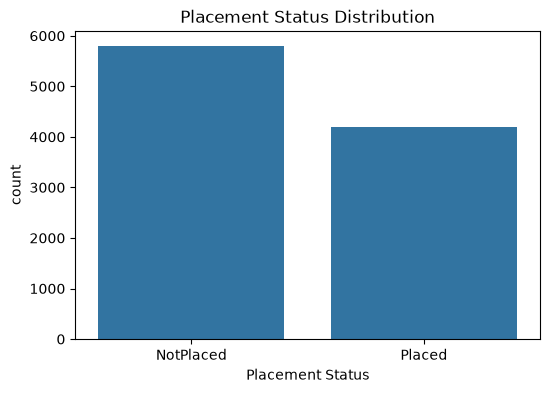

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="Placement Status", data=df)
plt.title("Placement Status Distribution")
plt.show()

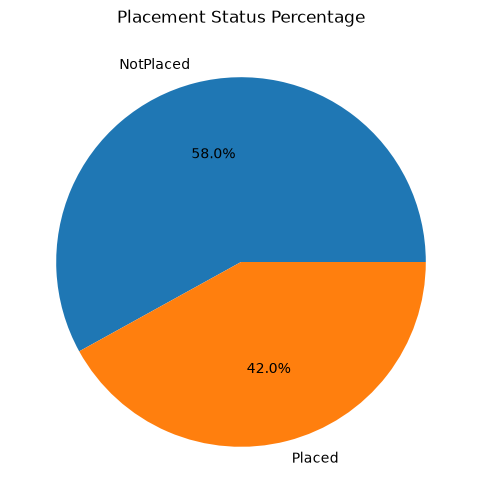

In [18]:
df["Placement Status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Placement Status Percentage")
plt.show()

In [19]:
df.dtypes

StudentID                      int64
CGPA                         float64
Internships                    int64
Projects                       int64
Workshops/Certifications       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities        str
PlacementTraining                str
SSC_Marks                      int64
HSC_Marks                      int64
Placement Status                 str
dtype: object

In [20]:
df.describe()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


Univariate Analysis

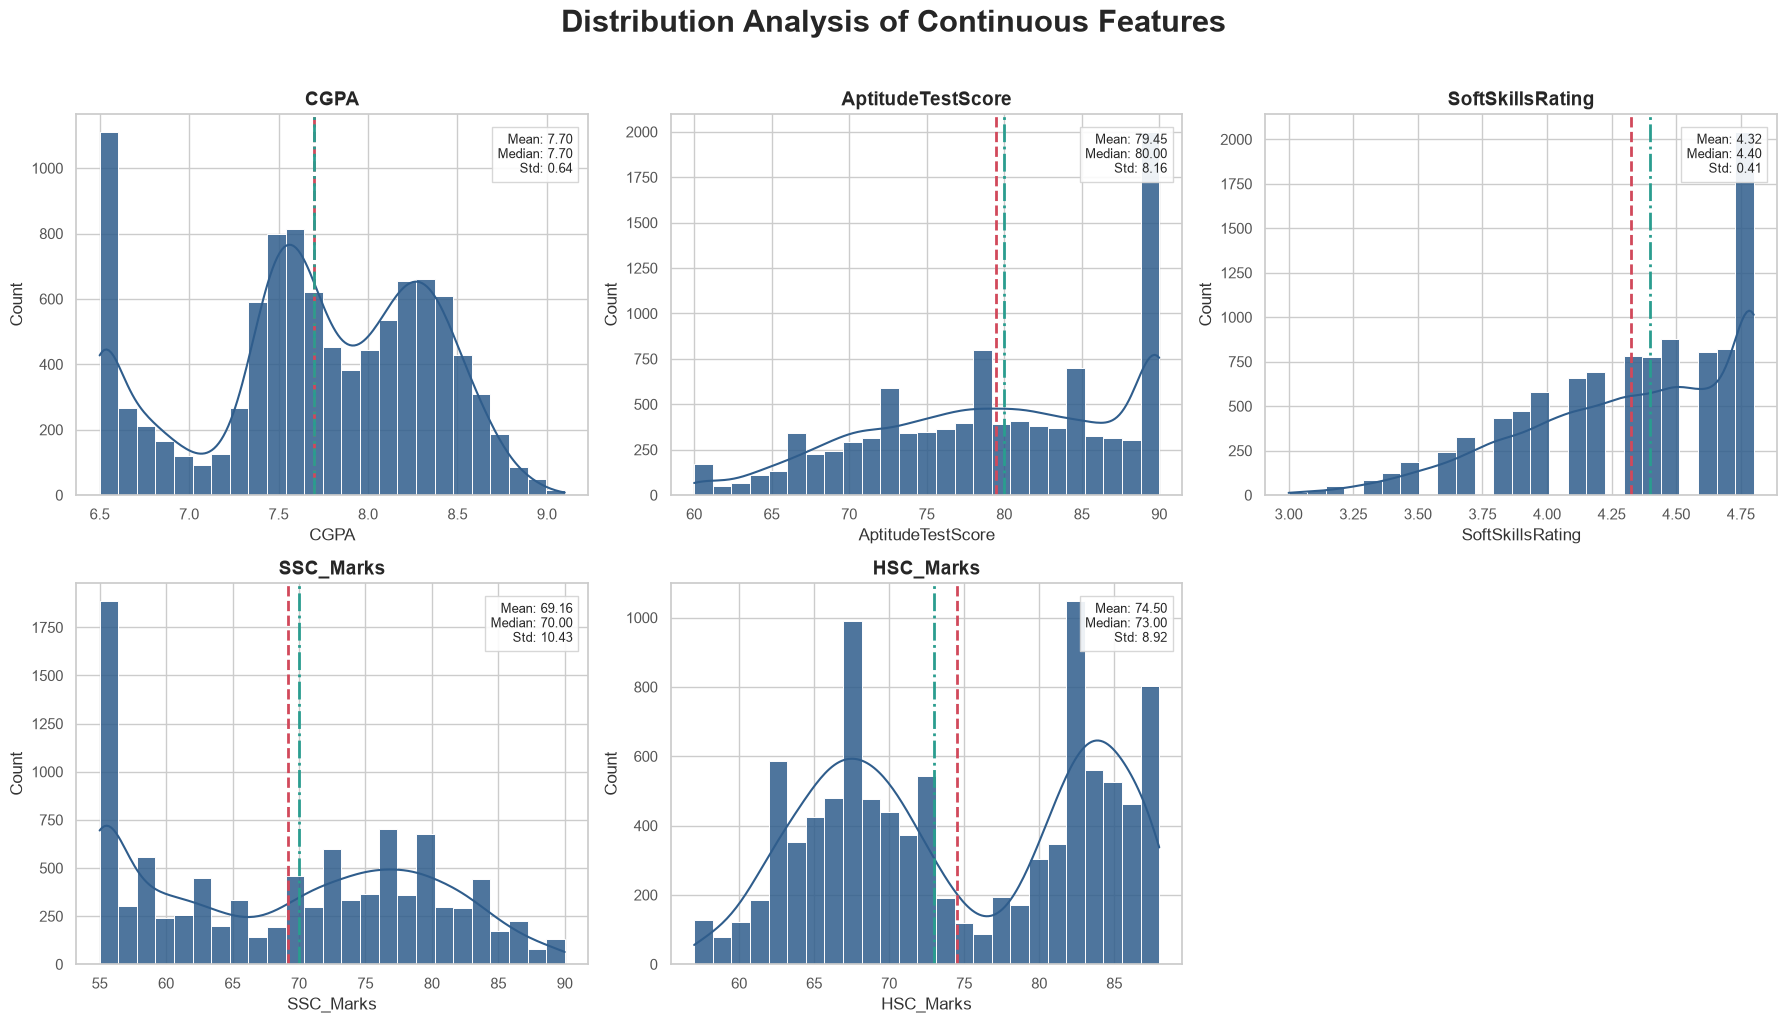

In [33]:
# ==========================================
# EXECUTIVE UNIVARIATE ANALYSIS
# Continuous Variables Dashboard
# ==========================================

continuous_cols = [
    'CGPA',
    'AptitudeTestScore',
    'SoftSkillsRating',
    'SSC_Marks',
    'HSC_Marks'
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10)
)

axes = axes.flatten()

palette_color = "#2F5D8C"

for i, col in enumerate(continuous_cols):

    ax = axes[i]

    sns.histplot(
        df[col],
        bins=25,
        kde=True,
        color=palette_color,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.7,
        ax=ax
    )

    mean_val = df[col].mean()
    median_val = df[col].median()

    ax.axvline(
        mean_val,
        color="#D1495B",
        linestyle="--",
        linewidth=2
    )

    ax.axvline(
        median_val,
        color="#2A9D8F",
        linestyle="-.",
        linewidth=2
    )

    ax.set_title(
        f"{col}",
        fontsize=14,
        fontweight="bold"
    )

    stats_text = (
        f"Mean: {mean_val:.2f}\n"
        f"Median: {median_val:.2f}\n"
        f"Std: {df[col].std():.2f}"
    )

    ax.text(
        0.97,
        0.95,
        stats_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(
            facecolor="white",
            alpha=0.9,
            edgecolor="lightgray"
        )
    )

# Remove empty subplot
fig.delaxes(axes[-1])

fig.suptitle(
    "Distribution Analysis of Continuous Features",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

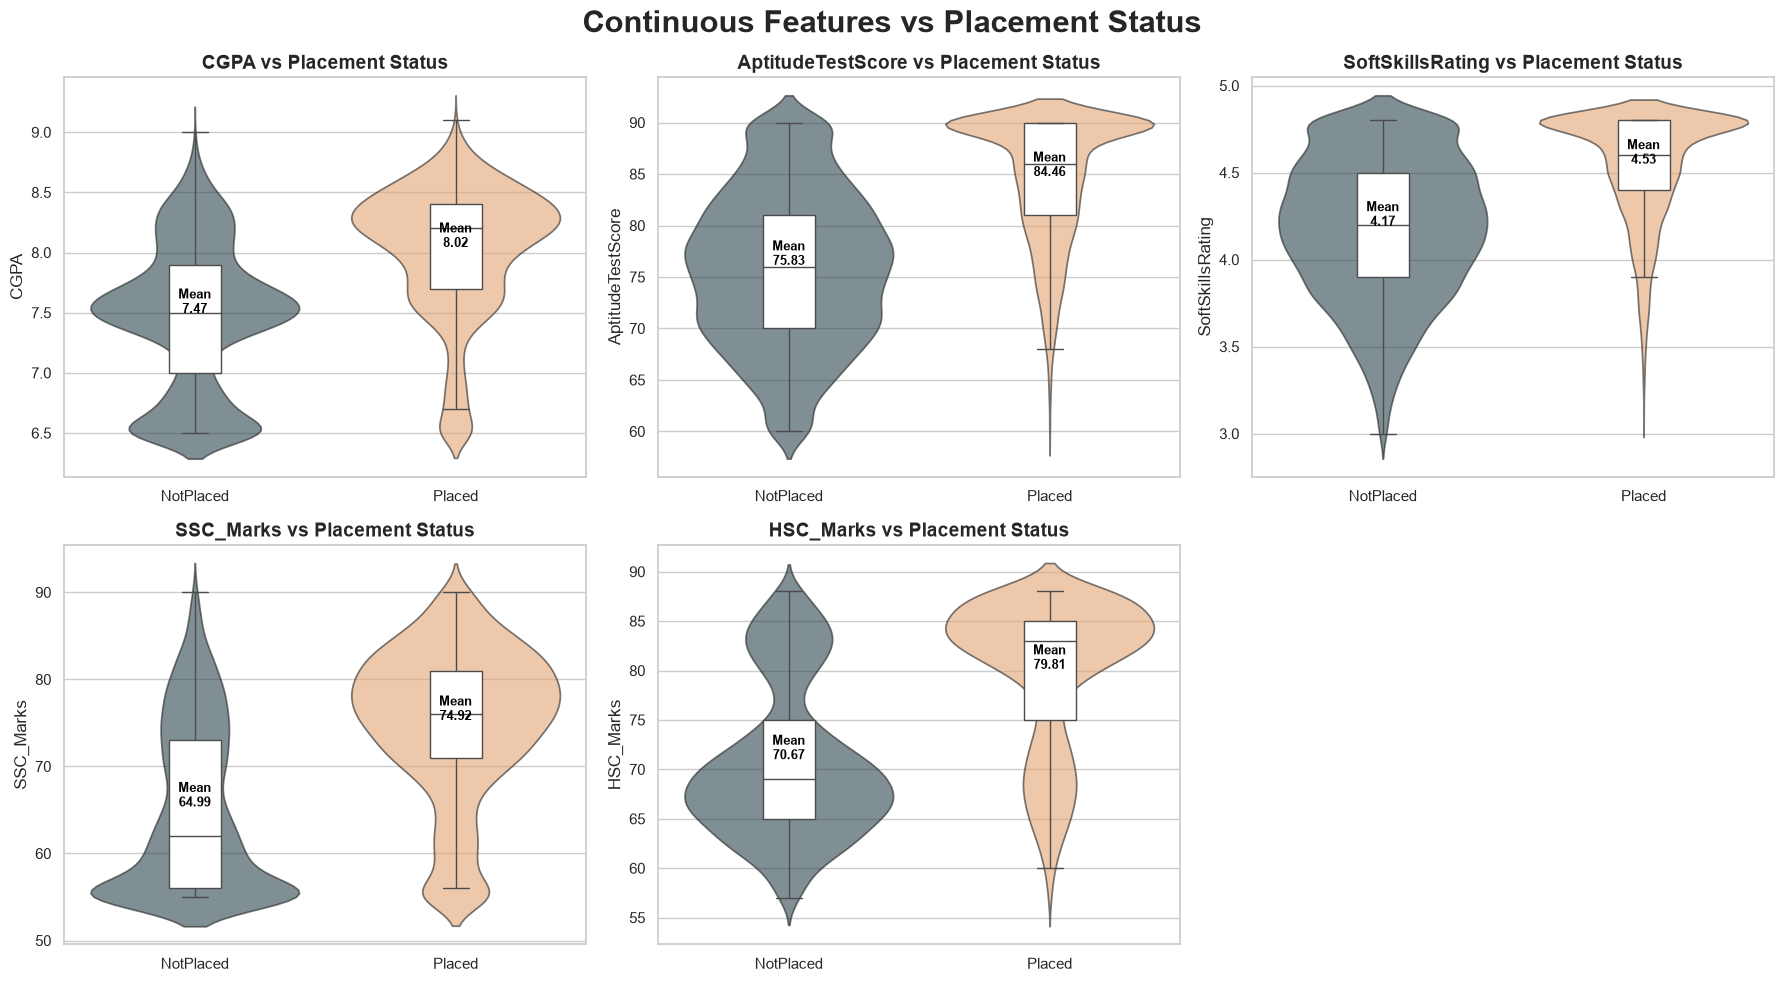

In [37]:
# ==========================================
# BIVARIATE ANALYSIS
# Continuous Features vs Placement Status
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

continuous_cols = [
    'CGPA',
    'AptitudeTestScore',
    'SoftSkillsRating',
    'SSC_Marks',
    'HSC_Marks'
]

# Executive Theme
sns.set_theme(style="whitegrid")

corporate_blue = "#264653"
corporate_orange = "#F4A261"

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10)
)

axes = axes.flatten()

for i, col in enumerate(continuous_cols):

    ax = axes[i]

    # Violin Plot
    sns.violinplot(
        data=df,
        x="Placement Status",
        y=col,
        hue="Placement Status",
        palette=[corporate_blue, corporate_orange],
        legend=False,
        inner=None,
        alpha=0.6,
        ax=ax
    )

    # Boxplot Overlay
    sns.boxplot(
        data=df,
        x="Placement Status",
        y=col,
        width=0.2,
        showcaps=True,
        boxprops={"facecolor":"white"},
        showfliers=False,
        ax=ax
    )

    # Mean Labels
    means = df.groupby("Placement Status")[col].mean()

    for j, value in enumerate(means):
        ax.text(
            j,
            value,
            f"Mean\n{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="black"
        )

    ax.set_title(
        f"{col} vs Placement Status",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel(col)

# Remove Empty Plot
fig.delaxes(axes[-1])

fig.suptitle(
    "Continuous Features vs Placement Status",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

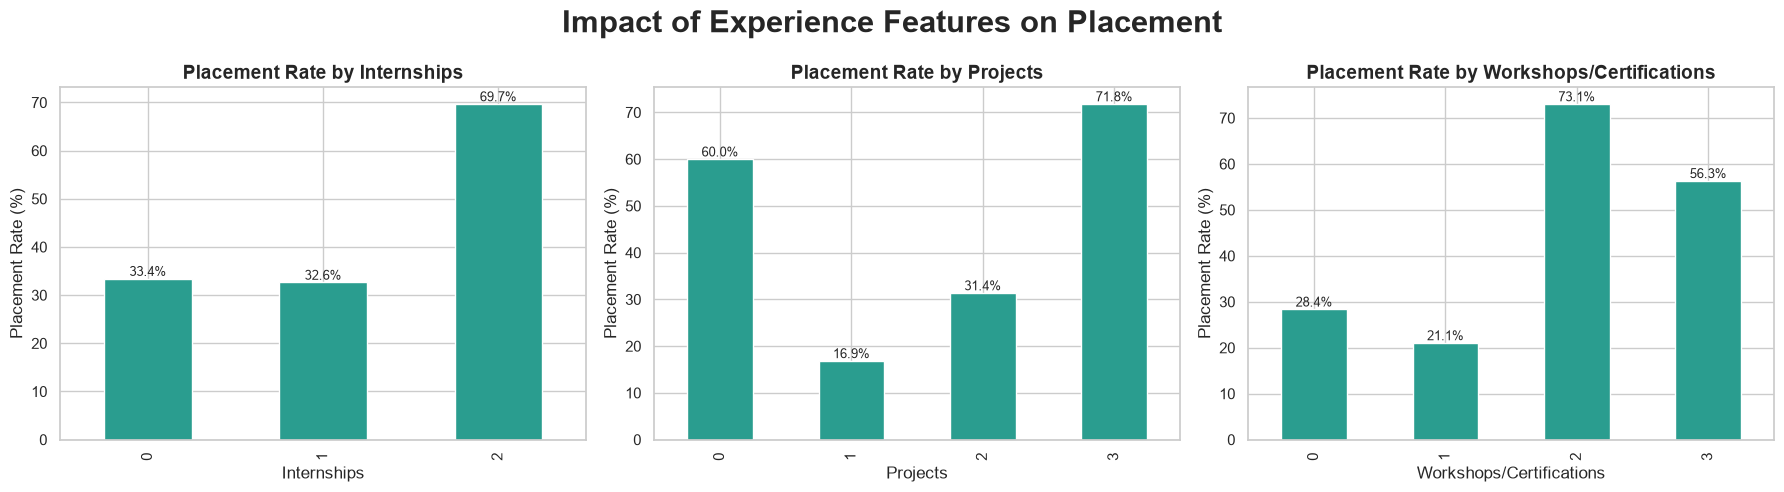

In [38]:
# ==========================================
# Placement Rate by Discrete Features
# ==========================================

discrete_cols = [
    'Internships',
    'Projects',
    'Workshops/Certifications'
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, col in zip(axes, discrete_cols):

    temp = (
        pd.crosstab(
            df[col],
            df["Placement Status"],
            normalize="index"
        ) * 100
    )

    temp["Placed"].plot(
        kind="bar",
        color="#2A9D8F",
        ax=ax
    )

    ax.set_title(
        f"Placement Rate by {col}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_ylabel("Placement Rate (%)")
    ax.set_xlabel(col)

    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.1f}%",
            (p.get_x()+p.get_width()/2,
             p.get_height()),
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.suptitle(
    "Impact of Experience Features on Placement",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

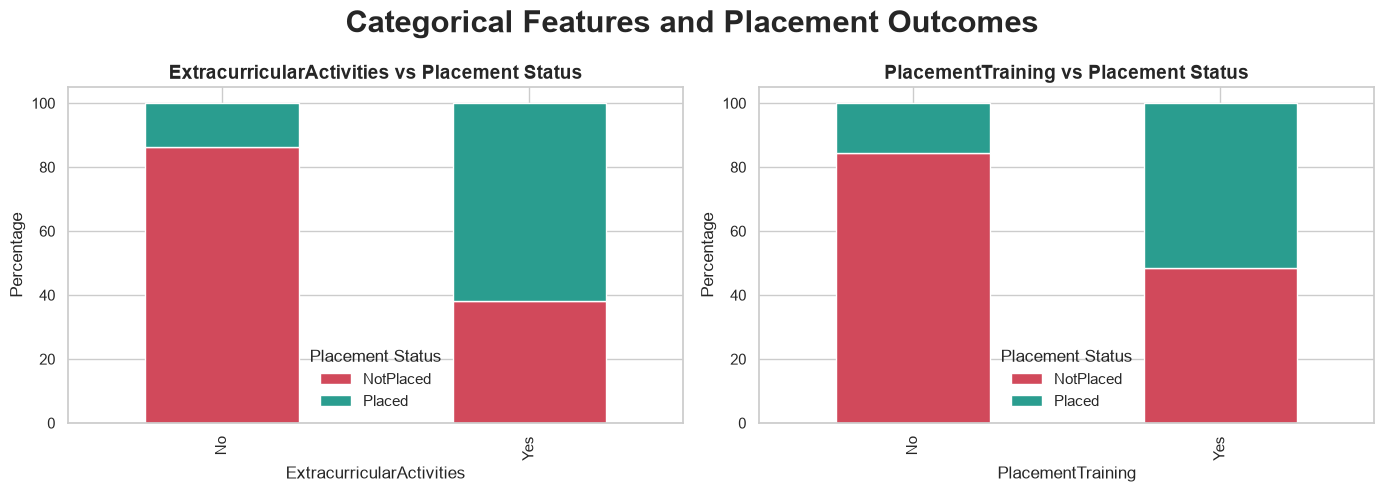

In [39]:
# ==========================================
# Categorical Features vs Placement Status
# ==========================================

cat_cols = [
    'ExtracurricularActivities',
    'PlacementTraining'
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

for ax, col in zip(axes, cat_cols):

    temp = (
        pd.crosstab(
            df[col],
            df["Placement Status"],
            normalize="index"
        ) * 100
    )

    temp.plot(
        kind="bar",
        stacked=True,
        color=["#D1495B", "#2A9D8F"],
        ax=ax
    )

    ax.set_title(
        f"{col} vs Placement Status",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_ylabel("Percentage")

    ax.legend(
        title="Placement Status",
        frameon=False
    )

plt.suptitle(
    "Categorical Features and Placement Outcomes",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Multivariate Analysis

In [40]:
# ==========================================
#        DATA FOR CORRELATION
# ==========================================

df_corr = df.copy()

df_corr["Placement Status"] = (
    df_corr["Placement Status"]
    .map({"NotPlaced":0,"Placed":1})
)

df_corr["ExtracurricularActivities"] = (
    df_corr["ExtracurricularActivities"]
    .map({"No":0,"Yes":1})
)

df_corr["PlacementTraining"] = (
    df_corr["PlacementTraining"]
    .map({"No":0,"Yes":1})
)

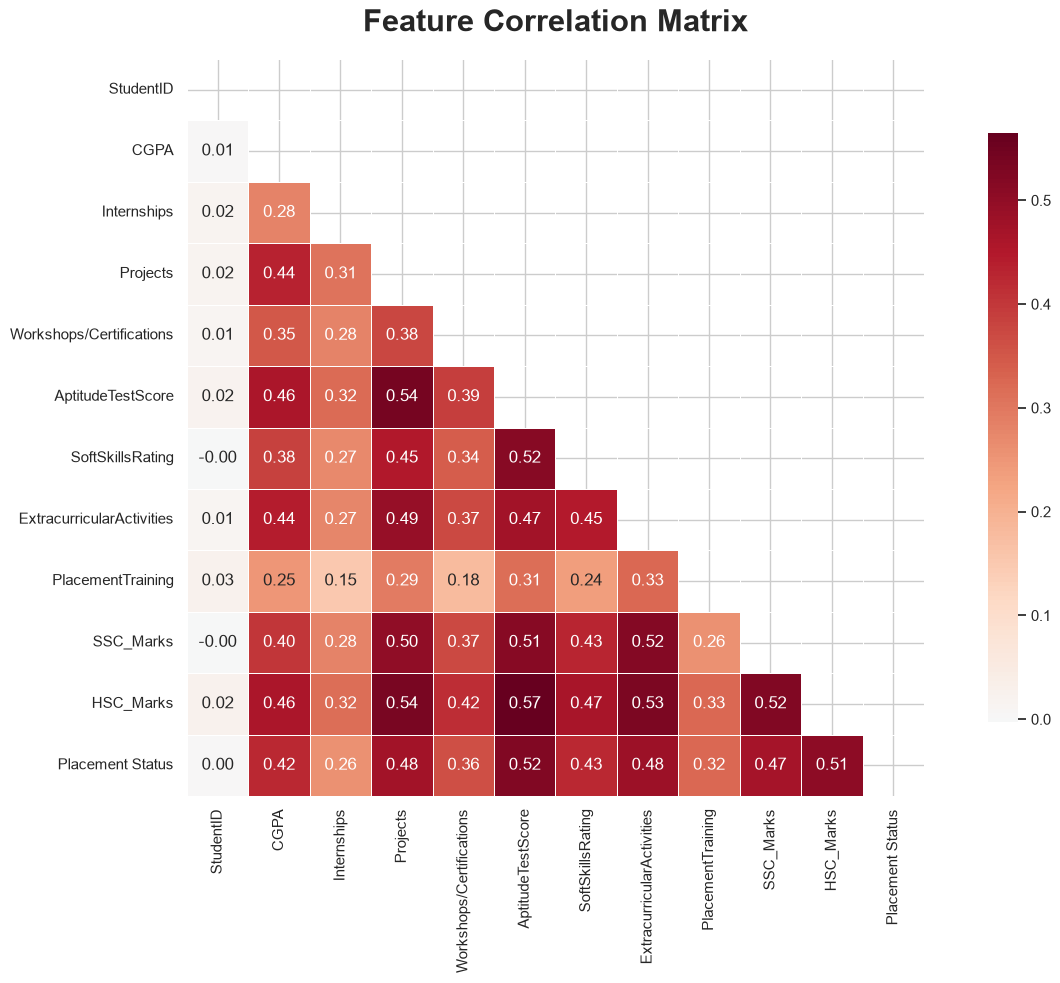

In [41]:
# ==========================================
# EXECUTIVE CORRELATION HEATMAP
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

corr_matrix = df_corr.corr(numeric_only=True)

mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool)
)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8}
)

plt.title(
    "Feature Correlation Matrix",
    fontsize=22,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

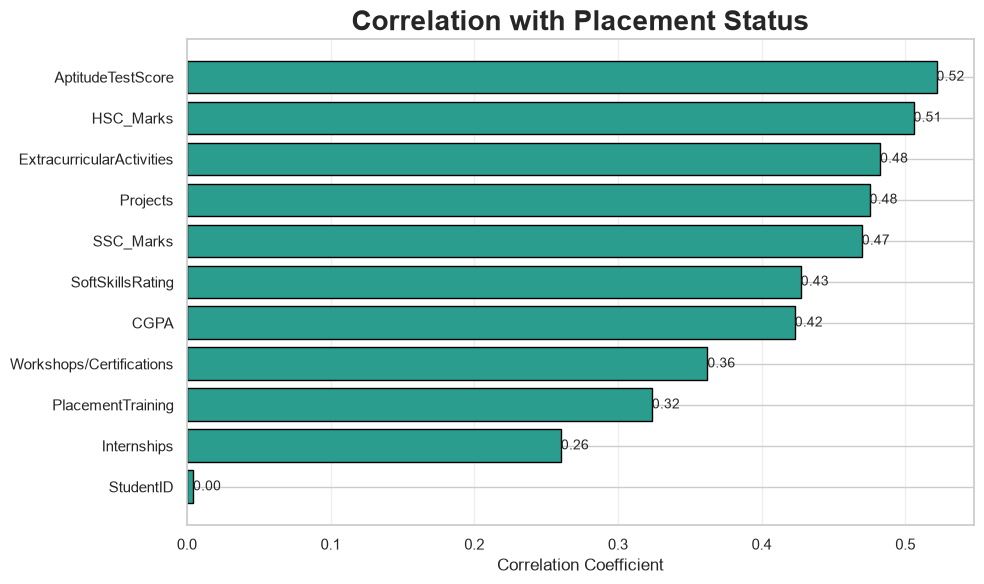

In [46]:
# ==========================================
# FEATURE IMPORTANCE BEFORE MODELING
# ==========================================

target_corr = (
    corr_matrix["Placement Status"]
    .drop("Placement Status")
    .sort_values()
)

plt.figure(figsize=(10,6))

colors = [
    "#D1495B" if x < 0 else "#2A9D8F"
    for x in target_corr.values
]

bars = plt.barh(
    target_corr.index,
    target_corr.values,
    color=colors,
    edgecolor="black"
)

plt.title(
    "Correlation with Placement Status",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Correlation Coefficient")

for bar in bars:

    width = bar.get_width()

    plt.text(
        width,
        bar.get_y()+bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        fontsize=10
    )

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

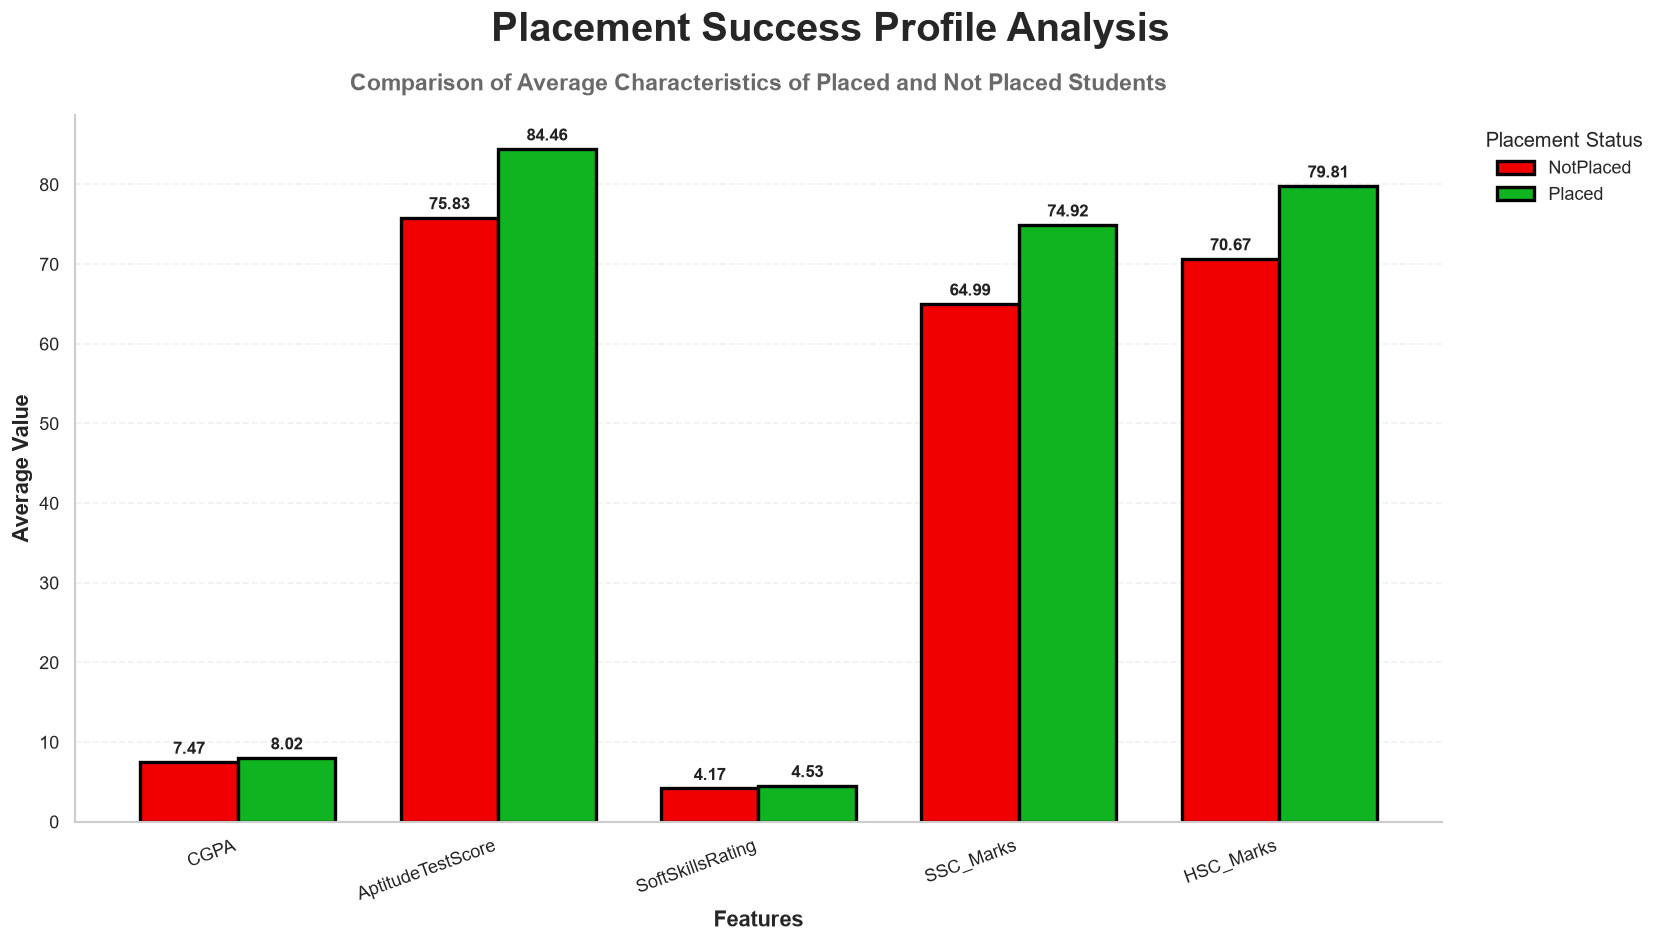

In [48]:
# ==========================================
# PLACEMENT SUCCESS PROFILE DASHBOARD
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ------------------------------------------
# Features to Compare
# ------------------------------------------

features = [
    'CGPA',
    'AptitudeTestScore',
    'SoftSkillsRating',
    'SSC_Marks',
    'HSC_Marks'
]

# ------------------------------------------
# Aggregate Mean Values
# ------------------------------------------

profile = (
    df.groupby("Placement Status")[features]
    .mean()
    .T
)

# ------------------------------------------
# Professional Theme
# ------------------------------------------

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titleweight": "bold"
})

# ------------------------------------------
# Create Figure
# ------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 8),
    dpi=120
)

# ------------------------------------------
# Corporate Color Palette
# ------------------------------------------

colors = [
    "#f10000",  # NotPlaced
    "#10b320"   # Placed
]

# ------------------------------------------
# Plot
# ------------------------------------------

bars = profile.plot(
    kind="bar",
    ax=ax,
    color=colors,
    edgecolor="black",
    linewidth=2.0,
    width=0.75
)

# ------------------------------------------
# Value Labels
# ------------------------------------------

for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=10,
        fontweight="bold",
        color="#222222"
    )

# ------------------------------------------
# Titles
# ------------------------------------------

fig.suptitle(
    "Placement Success Profile Analysis",
    fontsize=24,
    fontweight="bold",
    y=0.98
)

ax.set_title(
    "Comparison of Average Characteristics of Placed and Not Placed Students",
    fontsize=14,
    color="dimgray",
    pad=15
)

# ------------------------------------------
# Axis Labels
# ------------------------------------------

ax.set_xlabel(
    "Features",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Average Value",
    fontsize=13,
    fontweight="bold"
)

# ------------------------------------------
# Grid Styling
# ------------------------------------------

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.grid(
    axis="x",
    visible=False
)

# ------------------------------------------
# Tick Styling
# ------------------------------------------

plt.xticks(
    rotation=20,
    ha="right",
    fontsize=11
)

plt.yticks(fontsize=11)

# ------------------------------------------
# Legend Styling
# ------------------------------------------

ax.legend(
    title="Placement Status",
    title_fontsize=12,
    fontsize=11,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# ------------------------------------------
# Remove Top & Right Spines
# ------------------------------------------

sns.despine()

# ------------------------------------------
# Layout
# ------------------------------------------

plt.tight_layout()

plt.show()